In [3]:
import torch
import numpy as np
import gymnasium
import pathlib
import cma
import multiprocessing
device='cuda' if torch.cuda.is_available() else 'cpu'
print(device)
import random

class config:
  Z_DIM:int=32
  RNN_HIDDEN:int=256
  N_MIXTURE:int=5
  IMG:int=64
  ACTION_DIM:int=3
  KL_TOLERANCE:float=0.5

import torch.nn as nn
import torch.nn.functional as F
import os
pathlib.Path("data").mkdir(exist_ok=True)
pathlib.Path("ckpt").mkdir(exist_ok=True)

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

cuda


In [4]:
class CarRacingEnv:
  def __init__(self, seed=None):
    self.env=gymnasium.make("CarRacing-v3", continuous=True)
    self.seed=seed
  def reset(self):
    obs, info=self.env.reset(seed=self.seed)
    for _ in range(50):
      obs, _, _, _, _ = self.env.step(np.array([0.0, 0.0, 0.0], dtype=np.float32))
    return self.preprocess(obs)
  def step(self, action):
    obs, reward, terminated, truncated, info=self.env.step(action)
    done=terminated or truncated
    return self.preprocess(obs), reward, done, info
  def close(self):
    self.env.close()
  @staticmethod
  def preprocess(image):
    image_new=torch.from_numpy(image).permute(2,0,1).unsqueeze(0).float()/255.0

    image_new=F.interpolate(
        image_new,
        size=(64, 64),
        mode="bilinear",
        align_corners=False,

    )
    return image_new.squeeze(0)

In [7]:
for i in range(200):
  racing_env=CarRacingEnv(seed=i)
  racing_env.reset()
  observations=[]
  actions=[]
  current_action=None
  counter=0
  for j in range(1000):
    if counter==0:
      steer=np.random.uniform(-1.0,1.0)
      gas=np.random.uniform(0.3,1.0)
      brake=0.0
      action = np.array([steer, gas, brake], dtype=np.float32)
      #sample new action
      counter=10
    counter-=1
    obs, rewards, done, info=racing_env.step(action)
    observations.append((obs.numpy() * 255).astype(np.uint8))
    actions.append(action)
    if done:
      break

  obs_arr = np.stack(observations)            # (T, 3, 64, 64) uint8
  act_arr = np.stack(actions).astype(np.float32)  # (T, 3)
  np.savez_compressed(f"data/rollout_{i}.npz", obs=obs_arr, actions=act_arr)
  racing_env.close()

(950, 3, 64, 64) uint8
(950, 3) float32


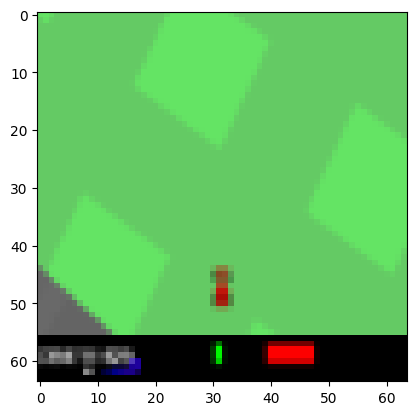

In [8]:
d = np.load("data/rollout_0.npz")
print(d["obs"].shape, d["obs"].dtype)      # expect (T, 3, 64, 64) uint8
print(d["actions"].shape, d["actions"].dtype)  # expect (T, 3) float32

import matplotlib.pyplot as plt
frame = d["obs"][100].transpose(1, 2, 0)   # (3,64,64) → (64,64,3) for imshow
plt.imshow(frame); plt.show()

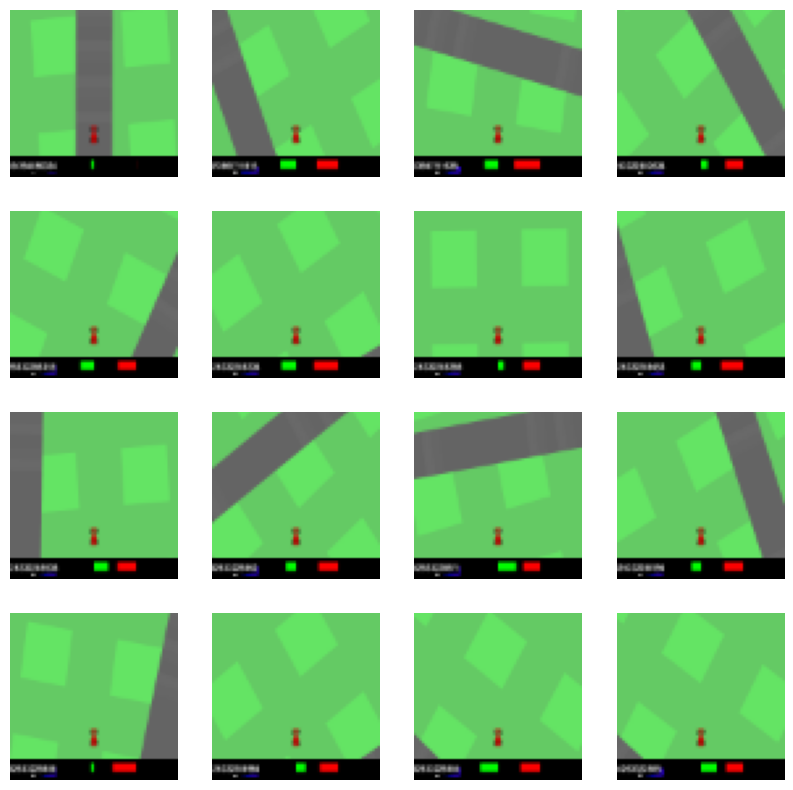

In [9]:
d = np.load("data/rollout_0.npz")
fig, ax = plt.subplots(4, 4, figsize=(10,10))
for k in range(16):
    f = d["obs"][k*60].transpose(1,2,0)   # every 60th frame across the rollout
    ax[k//4, k%4].imshow(f); ax[k//4, k%4].axis("off")
plt.show()

In [10]:
len(list(pathlib.Path("data").glob("*.npz"))) == 200

True

In [11]:
class VAE_encoder(nn.Module):
  def __init__(self):
    super().__init__()
    self.conv1=nn.Conv2d(3,32,4,2)
    self.relu1=nn.ReLU()
    self.conv2=nn.Conv2d(32,64,4,2)
    self.relu2=nn.ReLU()
    self.conv3=nn.Conv2d(64,128,4,2)
    self.relu3=nn.ReLU()
    self.conv4=nn.Conv2d(128,256,4,2)
    self.relu4=nn.ReLU()

    self.linear1=nn.Linear(1024,32)
    self.linear2=nn.Linear(1024,32)
  def forward(self, x):
    x=self.relu1(self.conv1(x))
    x=self.relu2(self.conv2(x))
    x=self.relu3(self.conv3(x))
    x=self.relu4(self.conv4(x))
    x=torch.flatten(x, start_dim=1)
    mu=self.linear1(x)
    log_var=self.linear2(x)
    return mu, log_var

class VAE_decoder(nn.Module):
  def __init__(self):
    super().__init__()
    self.linear1=nn.Linear(config.Z_DIM, 1024)
    self.relu1=nn.ReLU()
    self.conv1=nn.ConvTranspose2d(1024,128,5,2)
    self.relu2=nn.ReLU()
    self.conv2=nn.ConvTranspose2d(128,64,5,2)
    self.relu3=nn.ReLU()
    self.conv3=nn.ConvTranspose2d(64,32,6,2)
    self.relu4=nn.ReLU()
    self.conv4=nn.ConvTranspose2d(32,3,6,2)
    self.sigmoid=nn.Sigmoid()
  def forward(self, x):
    x=self.relu1(self.linear1(x))
    x=x.view(-1,1024,1,1)
    x=self.relu2(self.conv1(x))
    x=self.relu3(self.conv2(x))
    x=self.relu4(self.conv3(x))
    x=self.sigmoid(self.conv4(x))
    return x







In [12]:
enc = VAE_encoder().to(device)
dec = VAE_decoder().to(device)
x = torch.randn(4, 3, 64, 64).to(device)
mu, logvar = enc(x)
z = mu                              # just to test decode path
recon = dec(z)
print(mu.shape, logvar.shape, recon.shape)
# expect: (4,32) (4,32) (4,3,64,64)

torch.Size([4, 32]) torch.Size([4, 32]) torch.Size([4, 3, 64, 64])


In [13]:
class ConvVAE(nn.Module):
  def __init__(self):
    super().__init__()
    self.encoder=VAE_encoder()
    self.decoder=VAE_decoder()
  def forward(self, x):
    mu, logvar=self.encoder(x)

    std=torch.exp(0.5*logvar)
    eps=torch.randn_like(mu)

    z=mu+std*eps

    reconstruction=self.decoder(z)
    return reconstruction, mu, logvar

In [14]:
import glob
from torch.utils.data import Dataset, DataLoader

class Dataset(Dataset):
  def __init__(self, data_directory='/content/data/*.npz'):
    list_of_files=[]
    data=glob.glob(data_directory)
    for datapoint in data:
      d=np.load(datapoint)
      list_of_files.append(d["obs"])
    self.frames=np.concatenate(list_of_files, axis=0)
  def __len__(self):
    return len(self.frames)
  def __getitem__(self, idx):
    frame=self.frames[idx]
    return torch.from_numpy(frame).float()/255.0





In [16]:
dataset = Dataset()
print(len(dataset), dataset[0].shape, dataset[0].dtype, dataset[0].max())
# expect ~190000, (3,64,64), float32, ~1.0

189284 torch.Size([3, 64, 64]) torch.float32 tensor(0.8941)


In [17]:
loader=DataLoader(dataset, batch_size=64, shuffle=True, num_workers=2)
vae=ConvVAE().to(device)
opt=torch.optim.Adam(vae.parameters(), lr=1e-4)


In [18]:
for epoch in range(10):
    recon_sum, kl_sum, n = 0.0, 0.0, 0
    for b, batch in enumerate(loader):
        x = batch.to(device)
        recon, mu, logvar = vae(x)

        recon_loss = F.mse_loss(recon, x, reduction='sum') / x.size(0)
        kl = -0.5 * torch.sum(1 + logvar - mu**2 - torch.exp(logvar), dim=1)
        kl = torch.clamp(kl, min=config.KL_TOLERANCE * config.Z_DIM)
        kl_loss = kl.mean()
        loss = recon_loss + kl_loss

        opt.zero_grad(); loss.backward(); opt.step()

        recon_sum += recon_loss.item(); kl_sum += kl_loss.item(); n += 1
        if b % 500 == 0:
            print(f"epoch {epoch} batch {b}  recon {recon_loss.item():.1f}  kl {kl_loss.item():.2f}")

    print(f"== epoch {epoch}: recon {recon_sum/n:.1f}  kl {kl_sum/n:.2f}")
    torch.save(vae.state_dict(), "ckpt/vae.pt")

epoch 0 batch 0  recon 762.0  kl 16.00
epoch 0 batch 500  recon 82.1  kl 16.25
epoch 0 batch 1000  recon 51.0  kl 16.70
epoch 0 batch 1500  recon 44.0  kl 16.48
epoch 0 batch 2000  recon 33.7  kl 16.46
epoch 0 batch 2500  recon 31.6  kl 16.60
== epoch 0: recon 66.5  kl 16.51
epoch 1 batch 0  recon 31.8  kl 16.31
epoch 1 batch 500  recon 28.2  kl 16.36
epoch 1 batch 1000  recon 26.5  kl 16.73
epoch 1 batch 1500  recon 25.0  kl 16.63
epoch 1 batch 2000  recon 20.5  kl 16.81
epoch 1 batch 2500  recon 21.1  kl 16.96
== epoch 1: recon 24.2  kl 16.56
epoch 2 batch 0  recon 22.0  kl 16.74
epoch 2 batch 500  recon 22.2  kl 16.49
epoch 2 batch 1000  recon 19.8  kl 16.61
epoch 2 batch 1500  recon 18.2  kl 16.30
epoch 2 batch 2000  recon 19.2  kl 16.32
epoch 2 batch 2500  recon 19.8  kl 16.66
== epoch 2: recon 19.5  kl 16.54
epoch 3 batch 0  recon 18.0  kl 16.27
epoch 3 batch 500  recon 17.7  kl 16.54
epoch 3 batch 1000  recon 18.8  kl 16.70
epoch 3 batch 1500  recon 18.6  kl 16.56
epoch 3 batch 

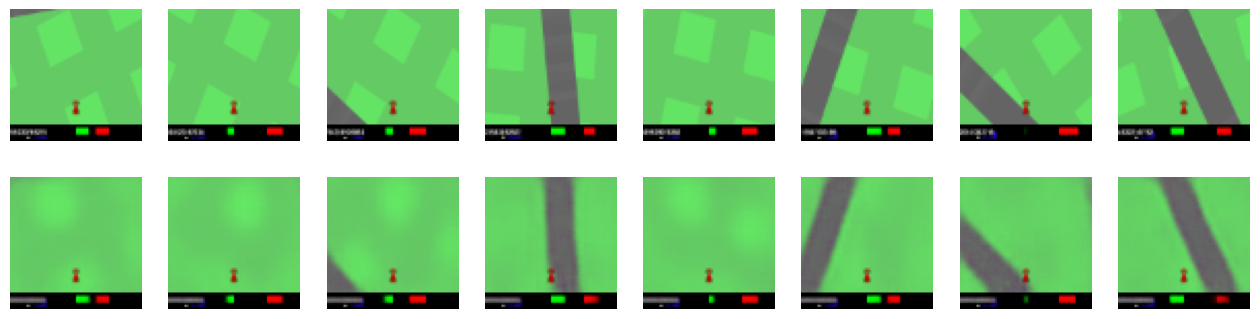

In [19]:
vae.eval()
with torch.no_grad():
    x = next(iter(loader))[:8].to(device)   # 8 frames
    recon, mu, logvar = vae(x)

x = x.cpu(); recon = recon.cpu()
fig, ax = plt.subplots(2, 8, figsize=(16, 4))
for i in range(8):
    ax[0, i].imshow(x[i].permute(1, 2, 0)); ax[0, i].axis("off")       # top row: originals
    ax[1, i].imshow(recon[i].permute(1, 2, 0)); ax[1, i].axis("off")  # bottom row: reconstructions
ax[0, 0].set_ylabel("orig"); ax[1, 0].set_ylabel("recon")
plt.show()

In [ ]:
val.eval()
